# Linear Classifier 실습

이 노트북은 선형 분류기의 핵심 개념을 직접 구현하면서 확인하는 실습입니다.

## 실습 목표
- 2차원 synthetic dataset 생성
- Multiclass SVM loss 기반 선형 분류기 구현
- Softmax loss 기반 선형 분류기 구현
- 두 모델의 추론 결과 비교
- decision boundary, confusion matrix, loss curve 시각화


In [1]:
import os
os.environ['MPLCONFIGDIR'] = '/tmp/matplotlib'

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

np.random.seed(42)
plt.rcParams['figure.dpi'] = 120

print('NumPy version:', np.__version__)


NumPy version: 2.1.3


## 1. 데이터 생성

세 개의 클래스를 가지는 2차원 데이터를 직접 만들고 학습/테스트 데이터로 분리합니다.


In [2]:
def make_blobs(n_per_class=120, std=0.8, seed=42):
    rng = np.random.RandomState(seed)
    centers = np.array([
        [-2.5, -1.5],
        [2.0, -1.0],
        [0.5, 2.5],
    ])

    X_parts, y_parts = [], []
    for class_id, center in enumerate(centers):
        points = rng.randn(n_per_class, 2) * std + center
        X_parts.append(points)
        y_parts.append(np.full(n_per_class, class_id, dtype=np.int64))

    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)
    return X, y


def train_test_split(X, y, test_ratio=0.25, seed=42):
    rng = np.random.RandomState(seed)
    indices = rng.permutation(len(X))
    split = int(len(X) * (1 - test_ratio))
    train_idx, test_idx = indices[:split], indices[split:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


X, y = make_blobs(n_per_class=140, std=0.9, seed=7)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_ratio=0.25, seed=7)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape)


X_train: (315, 2) y_train: (315,)
X_test : (105, 2) y_test : (105,)


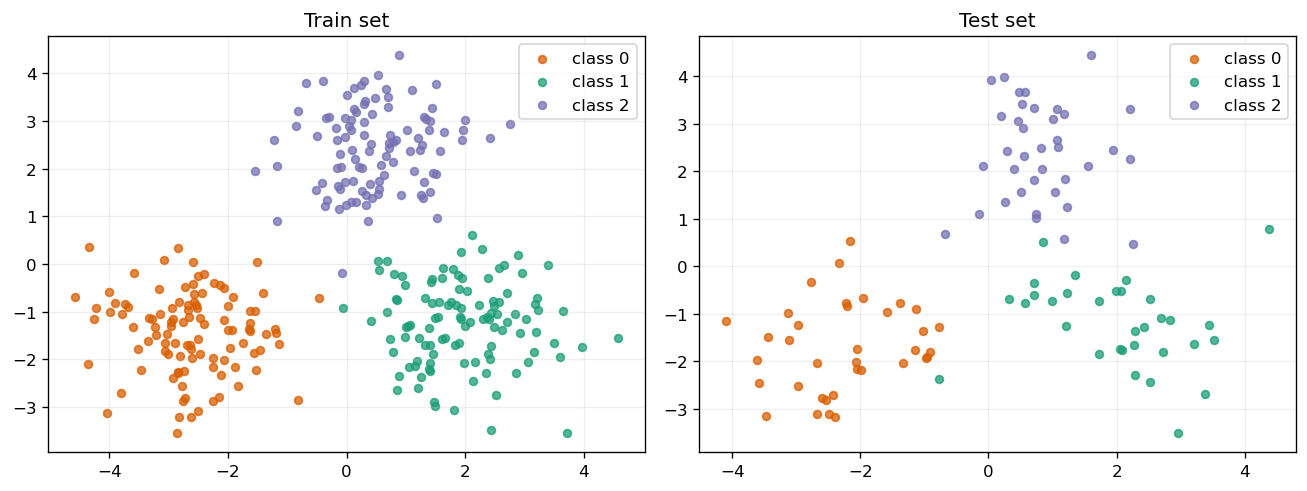

In [3]:
def plot_dataset(X_train, y_train, X_test, y_test):
    colors = ['#d95f02', '#1b9e77', '#7570b3']
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

    for cls in np.unique(y_train):
        axes[0].scatter(
            X_train[y_train == cls, 0],
            X_train[y_train == cls, 1],
            s=22,
            alpha=0.75,
            c=colors[cls],
            label=f'class {cls}'
        )
    axes[0].set_title('Train set')
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    for cls in np.unique(y_test):
        axes[1].scatter(
            X_test[y_test == cls, 0],
            X_test[y_test == cls, 1],
            s=22,
            alpha=0.75,
            c=colors[cls],
            label=f'class {cls}'
        )
    axes[1].set_title('Test set')
    axes[1].legend()
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


plot_dataset(X_train, y_train, X_test, y_test)


## 2. Linear Classifier 구현

입력 `X`와 가중치 `W`, 편향 `b`를 이용해 class score를 계산합니다.

\[
score = XW + b
\]

이후 loss 종류를 `svm` 또는 `softmax`로 바꿔가며 같은 구조의 선형 분류기를 학습합니다.


In [4]:
def compute_scores(X, W, b):
    return X @ W + b


def svm_loss_and_grad(X, y, W, b, reg=1e-3):
    N = X.shape[0]
    scores = compute_scores(X, W, b)
    correct_scores = scores[np.arange(N), y][:, None]
    margins = np.maximum(0, scores - correct_scores + 1.0)
    margins[np.arange(N), y] = 0

    loss = margins.sum() / N + 0.5 * reg * np.sum(W * W)

    binary = (margins > 0).astype(np.float64)
    binary[np.arange(N), y] = -binary.sum(axis=1)

    dW = X.T @ binary / N + reg * W
    db = binary.sum(axis=0) / N
    return loss, dW, db


def softmax_loss_and_grad(X, y, W, b, reg=1e-3):
    N = X.shape[0]
    scores = compute_scores(X, W, b)
    scores -= scores.max(axis=1, keepdims=True)

    exp_scores = np.exp(scores)
    probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)

    correct_logprobs = -np.log(probs[np.arange(N), y] + 1e-12)
    loss = correct_logprobs.mean() + 0.5 * reg * np.sum(W * W)

    dscores = probs.copy()
    dscores[np.arange(N), y] -= 1
    dscores /= N

    dW = X.T @ dscores + reg * W
    db = dscores.sum(axis=0)
    return loss, dW, db


def predict(X, W, b):
    scores = compute_scores(X, W, b)
    return np.argmax(scores, axis=1)


def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


In [5]:
def train_linear_classifier(
    X, y,
    num_classes,
    loss_type='svm',
    learning_rate=0.08,
    reg=1e-3,
    epochs=400,
    seed=0,
):
    rng = np.random.RandomState(seed)
    W = 0.01 * rng.randn(X.shape[1], num_classes)
    b = np.zeros(num_classes)
    history = []

    for epoch in range(epochs):
        if loss_type == 'svm':
            loss, dW, db = svm_loss_and_grad(X, y, W, b, reg=reg)
        elif loss_type == 'softmax':
            loss, dW, db = softmax_loss_and_grad(X, y, W, b, reg=reg)
        else:
            raise ValueError("loss_type must be 'svm' or 'softmax'")

        W -= learning_rate * dW
        b -= learning_rate * db
        history.append(loss)

    return W, b, np.array(history)


## 3. SVM / Softmax 학습

같은 데이터에 대해 두 모델을 각각 학습하고 정확도를 비교합니다.


In [6]:
num_classes = len(np.unique(y_train))

svm_W, svm_b, svm_history = train_linear_classifier(
    X_train, y_train,
    num_classes=num_classes,
    loss_type='svm',
    learning_rate=0.08,
    reg=1e-3,
    epochs=500,
    seed=1,
)

softmax_W, softmax_b, softmax_history = train_linear_classifier(
    X_train, y_train,
    num_classes=num_classes,
    loss_type='softmax',
    learning_rate=0.12,
    reg=1e-3,
    epochs=500,
    seed=1,
)

svm_pred_train = predict(X_train, svm_W, svm_b)
svm_pred_test = predict(X_test, svm_W, svm_b)
softmax_pred_train = predict(X_train, softmax_W, softmax_b)
softmax_pred_test = predict(X_test, softmax_W, softmax_b)

print(f'SVM train accuracy     : {accuracy(y_train, svm_pred_train):.4f}')
print(f'SVM test accuracy      : {accuracy(y_test, svm_pred_test):.4f}')
print(f'Softmax train accuracy : {accuracy(y_train, softmax_pred_train):.4f}')
print(f'Softmax test accuracy  : {accuracy(y_test, softmax_pred_test):.4f}')


SVM train accuracy     : 0.9968
SVM test accuracy      : 0.9714
Softmax train accuracy : 0.9968
Softmax test accuracy  : 0.9619


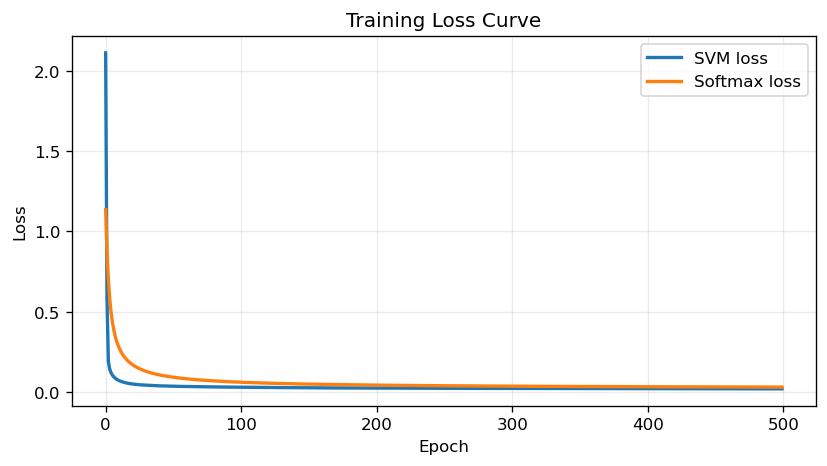

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(svm_history, label='SVM loss', linewidth=2)
plt.plot(softmax_history, label='Softmax loss', linewidth=2)
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.25)
plt.legend()
plt.show()


## 4. 추론 결과 확인

테스트 샘플 일부를 골라 정답 라벨과 두 모델의 예측 결과를 함께 확인합니다.


In [8]:
sample_count = 15
sample_indices = np.arange(min(sample_count, len(X_test)))

header = f"{'idx':>3} | {'x1':>8} {'x2':>8} | {'true':>4} | {'svm':>4} | {'softmax':>7}"
print(header)
print('-' * len(header))
for idx in sample_indices:
    x1, x2 = X_test[idx]
    print(f"{idx:>3} | {x1:>8.3f} {x2:>8.3f} | {y_test[idx]:>4d} | {svm_pred_test[idx]:>4d} | {softmax_pred_test[idx]:>7d}")


idx |       x1       x2 | true |  svm | softmax
-----------------------------------------------
  0 |   -2.050   -2.151 |    0 |    0 |       0
  1 |    0.198    3.170 |    2 |    2 |       2
  2 |   -4.089   -1.161 |    0 |    0 |       0
  3 |   -2.674   -3.100 |    0 |    0 |       0
  4 |    1.355   -0.179 |    1 |    1 |       1
  5 |   -2.770   -0.333 |    0 |    0 |       0
  6 |   -0.954   -1.912 |    0 |    0 |       0
  7 |    0.530    3.415 |    2 |    2 |       2
  8 |    2.214    2.248 |    2 |    2 |       2
  9 |    0.041    3.911 |    2 |    2 |       2
 10 |    0.243    3.993 |    2 |    2 |       2
 11 |   -1.152   -1.754 |    0 |    0 |       0
 12 |    0.286    2.429 |    2 |    2 |       2
 13 |    1.069    2.655 |    2 |    2 |       2
 14 |    2.058   -1.748 |    1 |    1 |       1


In [9]:
disagree_idx = np.where(svm_pred_test != softmax_pred_test)[0]
print('예측이 서로 다른 샘플 수:', len(disagree_idx))
print('처음 20개 index:', disagree_idx[:20])

if len(disagree_idx) > 0:
    print('\n서로 다른 예측 사례')
    header = f"{'idx':>3} | {'true':>4} | {'svm':>4} | {'softmax':>7}"
    print(header)
    print('-' * len(header))
    for idx in disagree_idx[:10]:
        print(f"{idx:>3} | {y_test[idx]:>4d} | {svm_pred_test[idx]:>4d} | {softmax_pred_test[idx]:>7d}")


예측이 서로 다른 샘플 수: 1
처음 20개 index: [64]

서로 다른 예측 사례
idx | true |  svm | softmax
---------------------------
 64 |    1 |    1 |       2


## 5. 추론 결과 비교 시각화

아래 그림에서는 두 모델의 decision boundary와 테스트 데이터에서의 정답/오답 분포를 비교합니다.


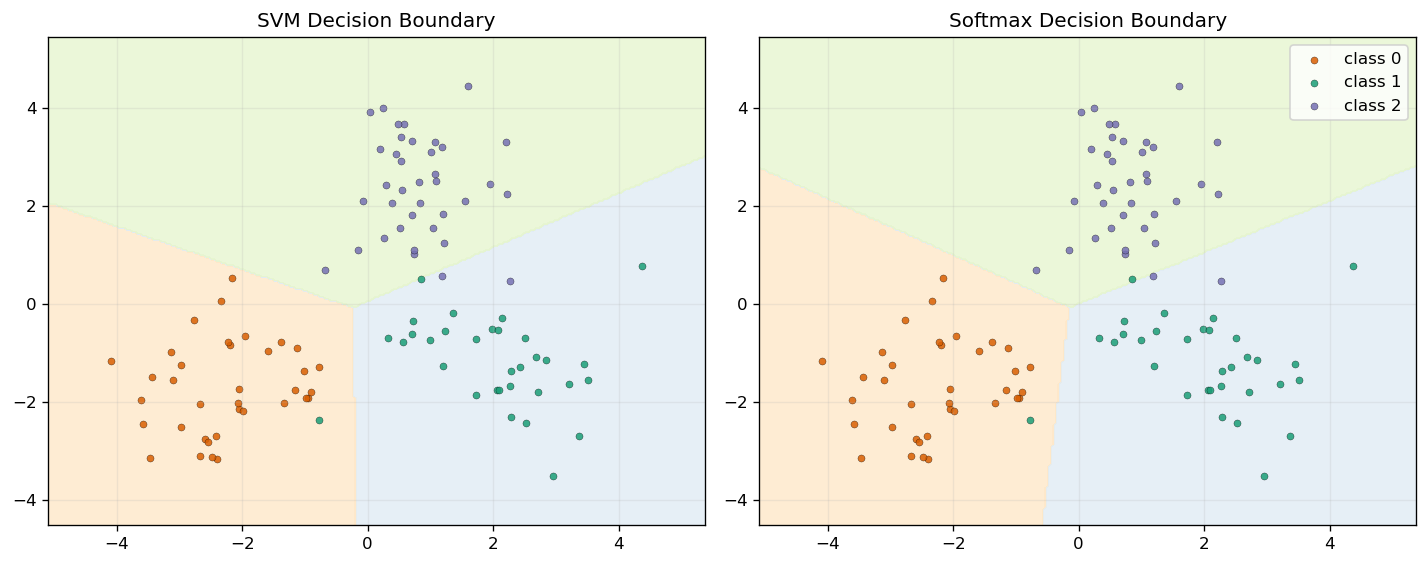

In [10]:
def plot_decision_boundary(ax, X, y, W, b, title):
    cmap_bg = ListedColormap(['#fee8c8', '#e0ecf4', '#e6f5d0'])
    cmap_pt = ['#d95f02', '#1b9e77', '#7570b3']

    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict(grid, W, b).reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.8)
    for cls in np.unique(y):
        ax.scatter(
            X[y == cls, 0],
            X[y == cls, 1],
            c=cmap_pt[cls],
            s=18,
            alpha=0.85,
            label=f'class {cls}',
            edgecolors='k',
            linewidths=0.2,
        )
    ax.set_title(title)
    ax.grid(alpha=0.2)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
plot_decision_boundary(axes[0], X_test, y_test, svm_W, svm_b, 'SVM Decision Boundary')
plot_decision_boundary(axes[1], X_test, y_test, softmax_W, softmax_b, 'Softmax Decision Boundary')
axes[1].legend(loc='upper right')
plt.tight_layout()
plt.show()


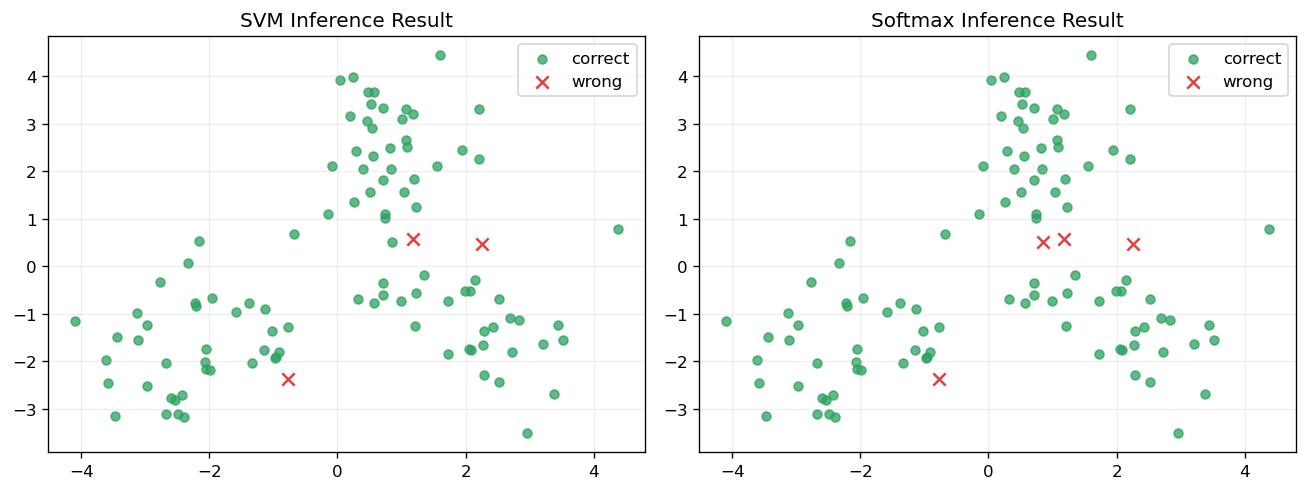

In [11]:
def plot_correct_wrong(ax, X, y_true, y_pred, title):
    correct = y_true == y_pred
    ax.scatter(X[correct, 0], X[correct, 1], c='#2ca25f', s=28, label='correct', alpha=0.75)
    ax.scatter(X[~correct, 0], X[~correct, 1], c='#de2d26', s=55, marker='x', label='wrong', alpha=0.9)
    ax.set_title(title)
    ax.grid(alpha=0.2)
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
plot_correct_wrong(axes[0], X_test, y_test, svm_pred_test, 'SVM Inference Result')
plot_correct_wrong(axes[1], X_test, y_test, softmax_pred_test, 'Softmax Inference Result')
plt.tight_layout()
plt.show()


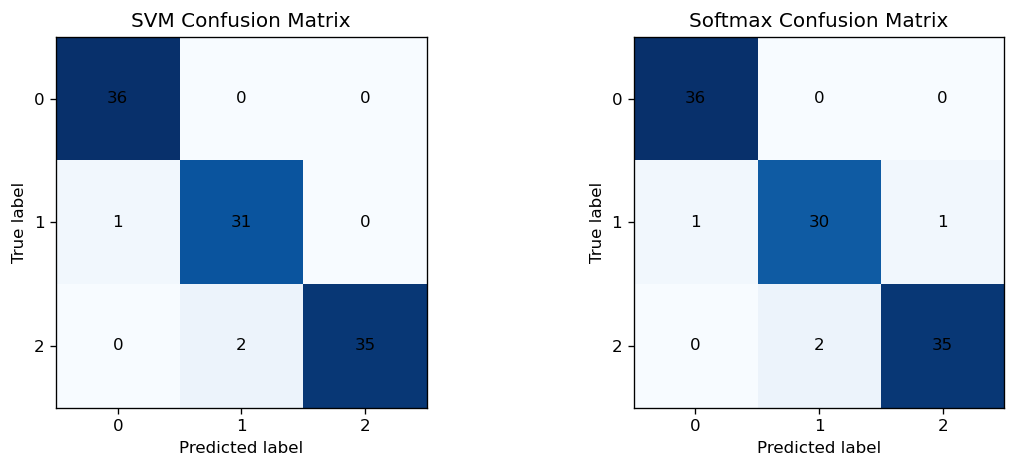

In [12]:
def confusion_matrix_np(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def draw_confusion_matrix(ax, cm, title):
    ax.imshow(cm, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_xticks(np.arange(cm.shape[1]))
    ax.set_yticks(np.arange(cm.shape[0]))
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')


svm_cm = confusion_matrix_np(y_test, svm_pred_test, num_classes)
softmax_cm = confusion_matrix_np(y_test, softmax_pred_test, num_classes)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
draw_confusion_matrix(axes[0], svm_cm, 'SVM Confusion Matrix')
draw_confusion_matrix(axes[1], softmax_cm, 'Softmax Confusion Matrix')
plt.tight_layout()
plt.show()


## 6. 실습 정리

### 관찰 포인트
- 두 모델 모두 선형 decision boundary를 사용하므로 데이터가 선형적으로 잘 나뉘는 경우 높은 성능을 보입니다.
- `SVM loss`는 정답 점수가 margin보다 충분히 크도록 만드는 방향으로 학습합니다.
- `Softmax loss`는 각 클래스의 확률 분포를 학습하며 정답 클래스의 확률을 높이는 방향으로 학습합니다.
- 실제 추론 결과에서는 비슷한 정확도가 나와도, 경계 근처 샘플에서 두 모델의 예측이 달라질 수 있습니다.
- confusion matrix와 오답 시각화를 함께 보면 어떤 클래스에서 실수가 발생하는지 더 쉽게 해석할 수 있습니다.

### 한 줄 요약
SVM은 margin 중심, Softmax는 확률 중심이라는 차이가 있고, 실습에서는 이 차이가 decision boundary와 경계 샘플 예측 차이로 드러납니다.


## 7. PDF 연습문제 풀이

아래 내용은 PDF 마지막의 연습문제(Exercise 1~4)를 현재 노트북 맥락에서 바로 실행할 수 있도록 정리한 풀이입니다.


In [13]:
# Exercise 1 & 2
scores_ex1 = np.array([
    [3.5, 2.0, 0.5],
    [1.0, 3.0, 2.5],
])
y_ex1 = np.array([0, 1])
delta = 1.0


def svm_loss_only(scores, y, delta=1.0):
    N = scores.shape[0]
    correct = scores[np.arange(N), y][:, None]
    margins = np.maximum(0, scores - correct + delta)
    margins[np.arange(N), y] = 0
    return margins.sum() / N, margins


def softmax_loss_only(scores, y):
    shifted = scores - scores.max(axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)
    loss = -np.log(probs[np.arange(len(y)), y]).mean()
    return loss, probs


svm_ex1_loss, margins_ex1 = svm_loss_only(scores_ex1, y_ex1, delta=delta)
softmax_ex1_loss, probs_ex1 = softmax_loss_only(scores_ex1, y_ex1)

print('[Exercise 1] SVM Loss 손계산 해석')
print('샘플 0: 정답 점수=3.5, margins = [0, max(0, 2.0-3.5+1), max(0, 0.5-3.5+1)] = [0, 0, 0]')
print('샘플 1: 정답 점수=3.0, margins = [max(0, 1.0-3.0+1), 0, max(0, 2.5-3.0+1)] = [0, 0, 0.5]')
print('평균 SVM Loss = (0 + 0.5) / 2 = 0.25')
print('코드 검증 SVM Loss =', round(svm_ex1_loss, 4))
print('margins:\n', margins_ex1)

print('\n[Exercise 2] Softmax + Cross-Entropy Loss')
print('Softmax probabilities:')
print(np.round(probs_ex1, 4))
print('Softmax Loss =', round(softmax_ex1_loss, 4))
print('\n비교: 이 예제에서는 SVM Loss가', round(svm_ex1_loss, 4), '이고 Softmax Loss가', round(softmax_ex1_loss, 4), '입니다.')
print('SVM은 margin을 넘기면 손실이 0이 되지만, Softmax는 정답 확률을 더 높이려는 성질 때문에 일반적으로 0에 바로 떨어지지 않습니다.')


[Exercise 1] SVM Loss 손계산 해석
샘플 0: 정답 점수=3.5, margins = [0, max(0, 2.0-3.5+1), max(0, 0.5-3.5+1)] = [0, 0, 0]
샘플 1: 정답 점수=3.0, margins = [max(0, 1.0-3.0+1), 0, max(0, 2.5-3.0+1)] = [0, 0, 0.5]
평균 SVM Loss = (0 + 0.5) / 2 = 0.25
코드 검증 SVM Loss = 0.25
margins:
 [[0.  0.  0. ]
 [0.  0.  0.5]]

[Exercise 2] Softmax + Cross-Entropy Loss
Softmax probabilities:
[[0.7856 0.1753 0.0391]
 [0.0777 0.5741 0.3482]]
Softmax Loss = 0.3981

비교: 이 예제에서는 SVM Loss가 0.25 이고 Softmax Loss가 0.3981 입니다.
SVM은 margin을 넘기면 손실이 0이 되지만, Softmax는 정답 확률을 더 높이려는 성질 때문에 일반적으로 0에 바로 떨어지지 않습니다.


[Exercise 3] XOR 문제 실험
예측값: [1 1 1 0]
정확도: 0.75
해석: XOR 데이터는 하나의 직선으로 두 클래스를 분리할 수 없으므로 선형 분류기로는 완벽하게 분류할 수 없습니다.


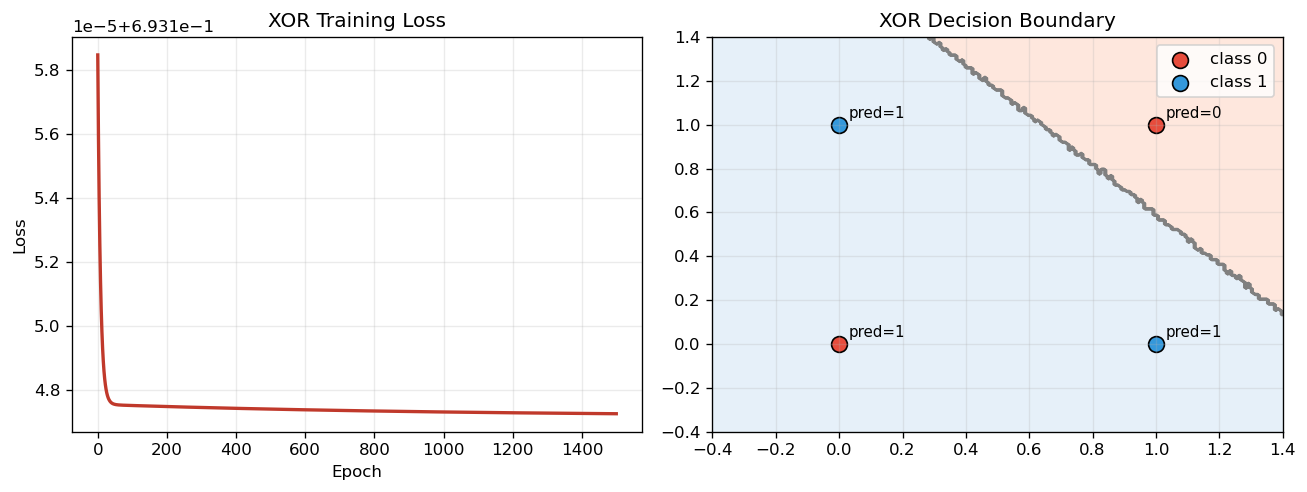

In [14]:
# Exercise 3
X_xor = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
])
y_xor = np.array([0, 1, 1, 0])

xor_W, xor_b, xor_history = train_linear_classifier(
    X_xor, y_xor,
    num_classes=2,
    loss_type='softmax',
    learning_rate=0.5,
    reg=1e-3,
    epochs=1500,
    seed=0,
)
xor_pred = predict(X_xor, xor_W, xor_b)
xor_acc = accuracy(y_xor, xor_pred)

print('[Exercise 3] XOR 문제 실험')
print('예측값:', xor_pred)
print('정확도:', xor_acc)
print('해석: XOR 데이터는 하나의 직선으로 두 클래스를 분리할 수 없으므로 선형 분류기로는 완벽하게 분류할 수 없습니다.')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(xor_history, color='#c0392b', lw=2)
axes[0].set_title('XOR Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.25)


def plot_xor_boundary(ax, W, b):
    x_min, x_max = -0.4, 1.4
    y_min, y_max = -0.4, 1.4
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict(grid, W, b).reshape(xx.shape)
    cmap_bg = ListedColormap(['#fee0d2', '#deebf7'])
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.75)
    ax.contour(xx, yy, Z, colors='gray', linewidths=1.2)
    ax.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], c='#e74c3c', s=90, label='class 0', edgecolors='k')
    ax.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], c='#3498db', s=90, label='class 1', edgecolors='k')
    for i, p in enumerate(xor_pred):
        ax.text(X_xor[i, 0] + 0.03, X_xor[i, 1] + 0.03, f'pred={p}', fontsize=9)
    ax.set_title('XOR Decision Boundary')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(alpha=0.25)
    ax.legend()


plot_xor_boundary(axes[1], xor_W, xor_b)
plt.tight_layout()
plt.show()


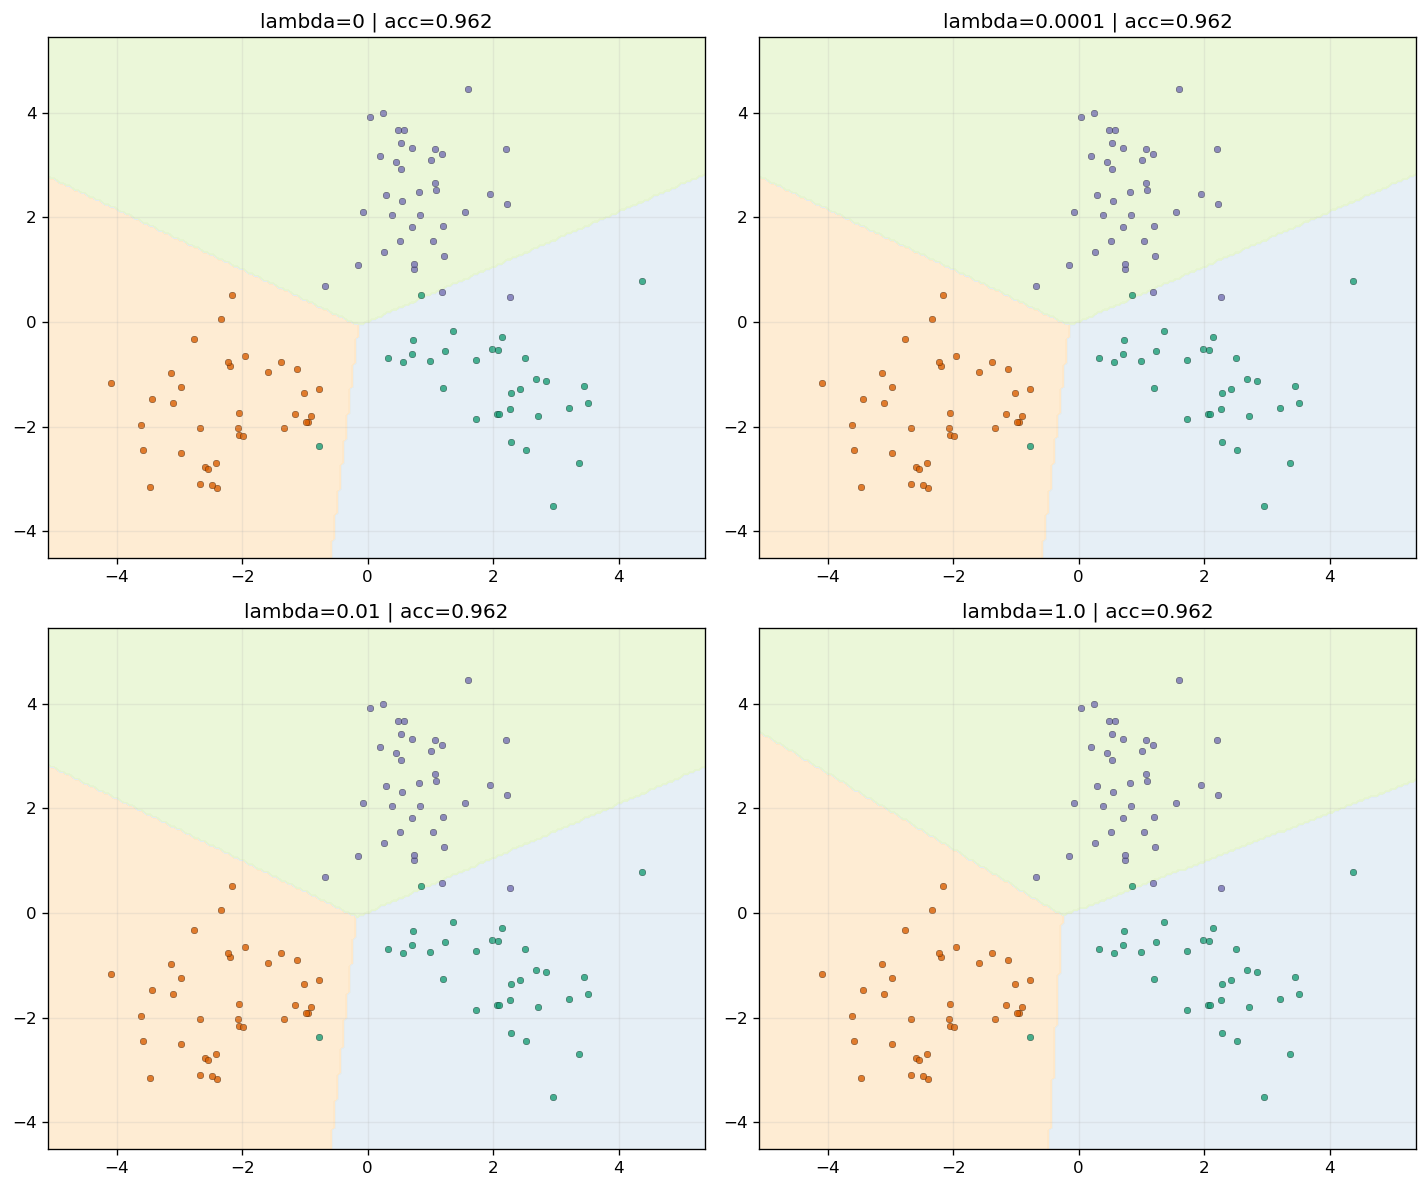

[Exercise 4] Regularization strength 비교
  lambda | final loss | test acc
----------------------------------
       0 |     0.0255 |   0.9619
  0.0001 |     0.0262 |   0.9619
    0.01 |     0.0762 |   0.9619
     1.0 |     0.6313 |   0.9619


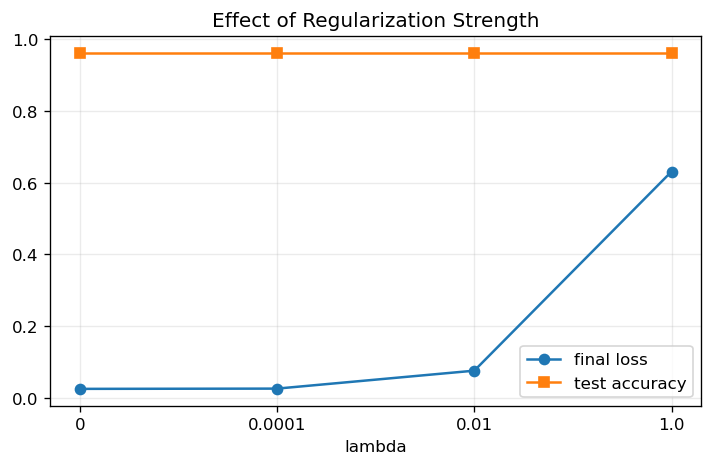

In [15]:
# Exercise 4
lambdas = [0, 1e-4, 1e-2, 1.0]
reg_results = []

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, lam in zip(axes, lambdas):
    W_reg, b_reg, history_reg = train_linear_classifier(
        X_train, y_train,
        num_classes=num_classes,
        loss_type='softmax',
        learning_rate=0.12,
        reg=lam,
        epochs=500,
        seed=1,
    )
    pred_reg = predict(X_test, W_reg, b_reg)
    acc_reg = accuracy(y_test, pred_reg)
    reg_results.append((lam, history_reg[-1], acc_reg))

    x_min, x_max = X_test[:, 0].min() - 1.0, X_test[:, 0].max() + 1.0
    y_min, y_max = X_test[:, 1].min() - 1.0, X_test[:, 1].max() + 1.0
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 220), np.linspace(y_min, y_max, 220))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict(grid, W_reg, b_reg).reshape(xx.shape)

    cmap_bg = ListedColormap(['#fee8c8', '#e0ecf4', '#e6f5d0'])
    colors = ['#d95f02', '#1b9e77', '#7570b3']
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.8)
    for cls in np.unique(y_test):
        ax.scatter(
            X_test[y_test == cls, 0],
            X_test[y_test == cls, 1],
            c=colors[cls],
            s=16,
            edgecolors='k',
            linewidths=0.2,
            alpha=0.8,
        )
    ax.set_title(f'lambda={lam} | acc={acc_reg:.3f}')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print('[Exercise 4] Regularization strength 비교')
print(f"{'lambda':>8} | {'final loss':>10} | {'test acc':>8}")
print('-' * 34)
for lam, final_loss, acc_reg in reg_results:
    print(f'{lam:>8} | {final_loss:>10.4f} | {acc_reg:>8.4f}')

plt.figure(figsize=(7, 4))
plt.plot([str(lam) for lam, _, _ in reg_results], [loss for _, loss, _ in reg_results], marker='o', label='final loss')
plt.plot([str(lam) for lam, _, _ in reg_results], [acc for _, _, acc in reg_results], marker='s', label='test accuracy')
plt.title('Effect of Regularization Strength')
plt.xlabel('lambda')
plt.grid(alpha=0.25)
plt.legend()
plt.show()


### 연습문제 해설 요약

- `Exercise 1`: 주어진 점수 행렬의 SVM Loss는 `0.25`입니다. 두 번째 샘플의 세 번째 클래스만 margin을 위반합니다.
- `Exercise 2`: 같은 점수에서 Softmax + Cross-Entropy Loss는 `0`보다 큰 값을 가지며, 정답 확률을 얼마나 높였는지까지 반영합니다.
- `Exercise 3`: XOR은 선형 분리 불가능 데이터이므로 단일 선형 분류기로는 완전히 해결되지 않습니다. decision boundary가 한 개의 직선 형태로만 나오기 때문입니다.
- `Exercise 4`: `lambda`가 너무 크면 가중치가 과하게 억제되어 경계가 단순해지고 성능이 떨어질 수 있습니다. 너무 작으면 규제가 약해집니다. 적절한 값은 데이터에 따라 달라집니다.
